In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import unidecode

df = pd.read_excel(r"C:\Users\samue\Desktop\Planilhas TCC\Matriz de Correlação\Base_de_Dados_IDSC-BR_2025.xlsx")
df.columns = df.columns.str.strip()

#Listar municípios
municipios_araguaina = [
    "Ananás", "Angico", "Aragominas", "Araguaína", "Araguanã",
    "Arapoema", "Babaçulândia", "Barra do Ouro", "Campos Lindos",
    "Carmolândia", "Darcinópolis", "Filadélfia", "Goiatins",
    "Muricilândia", "Nova Olinda", "Pau-d’Arco", "Piraquê",
    "Riachinho", "Santa Fé do Araguaia", "Wanderlândia", "Xambioá"
]

#Remover espaços da coluna Município
df["Município"] = df["Município"].str.strip()

#Filtrar município por UF
df_filtrado = df[
    (df["Município"].isin(municipios_araguaina)) &
    (df["UF"] == "TO")
]

#Selecionar colunas das 17 ODS
ods_cols = [f"Goal {i} Score" for i in range(1, 18)]

df_ods = df_filtrado[["Município"] + ods_cols]

#Exibir tabela formatada (igual ao outro exemplo)
from IPython.display import display
display(df_ods)


,Município,Goal 1 Score,Goal 2 Score,Goal 3 Score,Goal 4 Score,Goal 5 Score,Goal 6 Score,Goal 7 Score,Goal 8 Score,Goal 9 Score,Goal 10 Score,Goal 11 Score,Goal 12 Score,Goal 13 Score,Goal 14 Score,Goal 15 Score,Goal 16 Score,Goal 17 Score
316,Ananás,46.530562,45.972537,70.984756,59.993709,56.137051,48.884030,75.378333,42.131711,6.613742,42.867625,64.751010,35.083319,40.382822,10.383,16.398987,64.006193,12.179567
317,Angico,38.630462,49.902340,60.361393,60.638510,54.438157,69.141007,74.618056,42.561806,2.129874,64.976311,78.788318,71.363636,42.942331,0.000,28.633436,47.844728,25.038601
319,Aragominas,32.493949,47.941424,78.926936,58.582791,52.707981,57.611056,74.533981,32.422502,2.987523,71.911496,65.118535,100.000000,42.777423,0.000,1.131444,87.301667,6.926954
322,Araguaína,55.896493,47.771473,68.133444,60.346638,44.659615,73.359855,83.924537,46.719978,14.619917,50.267621,49.468379,34.546636,43.337546,24.896,28.019288,41.089965,30.045960
323,Araguanã,41.671573,51.190704,75.655639,58.407195,49.862237,75.420976,71.611481,37.915734,3.279806,51.593808,69.100928,35.523250,46.671902,0.000,20.811250,58.077684,11.184773
325,Arapoema,42.867481,32.770082,67.514129,53.983735,52.880003,43.243757,78.160185,54.181367,8.599615,55.827256,74.325609,100.000000,51.636483,0.000,14.103107,36.145035,34.123464
330,Babaçulândia,35.623527,34.637791,72.027963,59.104507,46.616415,75.432258,44.041481,38.858350,3.004898,71.912113,78.440426,50.833194,40.407362,0.000,23.027665,77.381000,14.631343
332,Barra do Ouro,40.008249,49.306989,71.699820,55.489849,56.459093,70.900788,35.683056,27.209057,12.384060,47.928904,65.726016,100.000000,39.042945,0.000,3.217025,32.142833,26.770387
340,Campos Lindos,51.451288,50.970589,68.777903,43.658181,53.827788,76.099745,34.259259,32.101144,4.732390,54.621538,70.436028,51.191468,40.445153,0.000,25.612154,74.692974,18.632110
342,Carmolândia,43.471425,50.371768,74.254384,50.739457,44.933631,66.066180,78.264907,39.892390,2.063309,78.585881,76.794286,70.000000,48.630757,0.000,20.599522,79.761833,9.033277


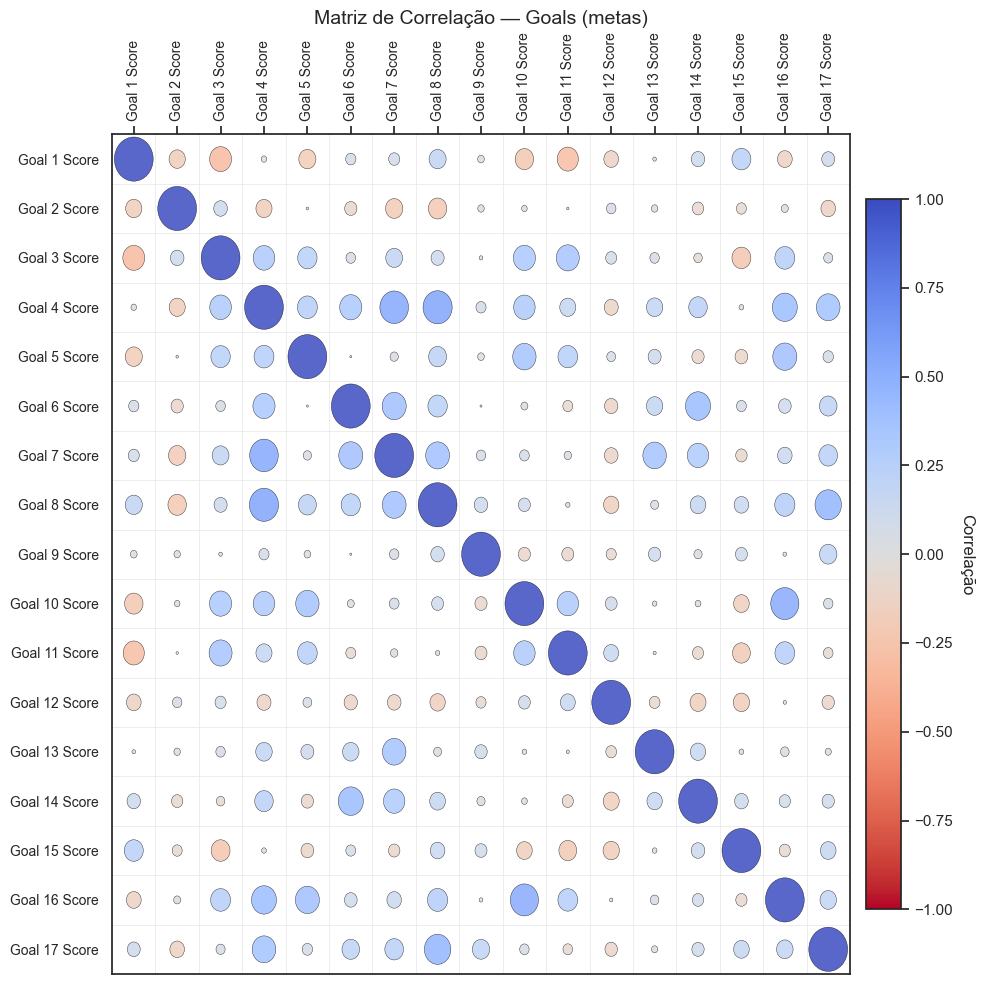

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib


#Carregar Excel localmente 
df_ods = pd.read_excel(
    r"C:\Users\samue\Desktop\Planilhas TCC\Matriz de Correlação\Base_de_Dados_IDSC-BR_2025.xlsx"
)

#Selecionar colunas
score_cols = [col for col in df_ods.columns if "Goal" in col and "Score" in col]

#converter para numero
for col in score_cols:
    df_ods[col] = pd.to_numeric(df_ods[col], errors="coerce")

#matriz de correlação
corr = df_ods[score_cols].corr()


#Preencher triângulo superior
corr_upper = corr.copy()
for i in range(corr.shape[0]):
    for j in range(i+1, corr.shape[1]): 
        corr_upper.iat[i, j] = corr.iat[j, i]   


#Plot gráfico de bolhas
n = len(corr_upper)
fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)

cmap = matplotlib.colormaps.get_cmap("coolwarm_r")
norm = Normalize(vmin=-1, vmax=1)

for i in range(n):
    for j in range(n):
        coef = corr_upper.iat[i, j]

        if np.isnan(coef):
            ax.text(j, i, "?", ha="center", va="center",
                    color="black", fontsize=12, fontweight="bold")
        else:
            size = (abs(coef) ** 1.0) * 2000
            color = cmap(norm(coef))
            circle = plt.Circle(
                (j, i),
                radius=np.sqrt(size) / 100.0,
                color=color,
                alpha=0.85,
                ec="black",
                linewidth=0.3,
            )
            ax.add_patch(circle)

#ticks
ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))

#coloca o nome das variáveis em cima
ax.xaxis.tick_top()  
ax.set_xticklabels(score_cols, rotation=90, fontsize=10)
ax.set_yticklabels(score_cols, fontsize=10)


#linha grid
for k in range(n):
    ax.axhline(k - 0.5, color="#e6e6e6", linewidth=0.5)
    ax.axvline(k - 0.5, color="#e6e6e6", linewidth=0.5)

#barra de cor
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.02)
cbar.set_label("Correlação", rotation=270, labelpad=15)

ax.set_title("Matriz de Correlação — Goals (metas)", fontsize=14)

plt.tight_layout()
plt.show()


Municípios finais: 21
["Pau D'Arco " 'Ananás ' 'Angico ' 'Aragominas ' 'Araguaína ' 'Araguanã '
 'Arapoema ' 'Babaçulândia ' 'Barra do Ouro ' 'Campos Lindos '
 'Carmolândia ' 'Darcinópolis ' 'Filadélfia ' 'Goiatins ' 'Muricilândia '
 'Nova Olinda ' 'Piraquê ' 'Riachinho ' 'Santa Fé do Araguaia '
 'Wanderlândia ' 'Xambioá ']


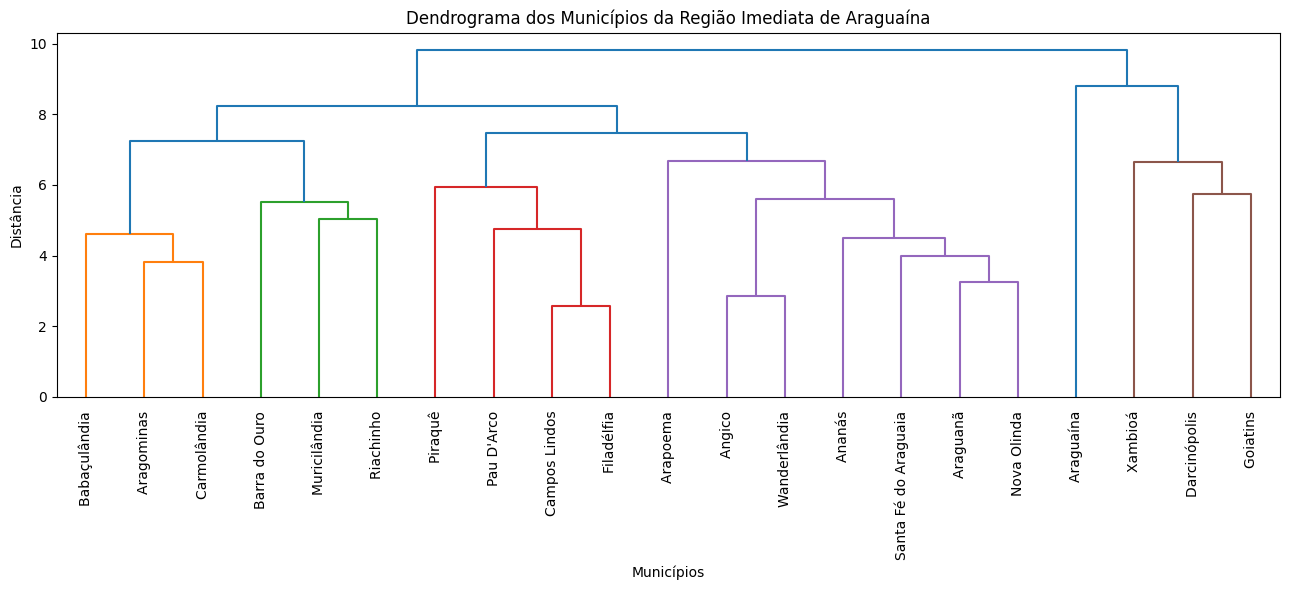

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler


#FUNÇÃO PARA NORMALIZAR NOMES
def normalizar_nome(texto):
    if pd.isna(texto):
        return texto
    texto = texto.lower().strip()
    texto = texto.replace("-", " ").replace("’", "'")
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ASCII', 'ignore').decode('ASCII')
    texto = " ".join(texto.split())
    return texto

#LISTA DOS 21 MUNICÍPIOS
municipios_araguaina = [
    "Ananás", "Angico", "Aragominas", "Araguaína", "Araguanã",
    "Arapoema", "Babaçulândia", "Barra do Ouro", "Campos Lindos",
    "Carmolândia", "Darcinópolis", "Filadélfia", "Goiatins",
    "Muricilândia", "Nova Olinda", "Pau D'Arco", "Piraquê",
    "Riachinho", "Santa Fé do Araguaia", "Wanderlândia", "Xambioá"
]

municipios_norm = [normalizar_nome(m) for m in municipios_araguaina]

#NORMALIZAR NOMES NA BASE
df_ods["Município"] = df_ods["Município"].astype(str)
df_ods["municipio_norm"] = df_ods["Município"].apply(normalizar_nome)


#FILTRAR OS 21 MUNICÍPIOS
df_sel = df_ods[df_ods["municipio_norm"].isin(municipios_norm)].copy()

#Remover duplicatas
df_sel = df_sel.drop_duplicates(subset="municipio_norm")

print("Municípios finais:", len(df_sel))
print(df_sel["Município"].values)

#SELEÇÃO DAS ODS
score_cols = [c for c in df_sel.columns if "Goal" in c and "Score" in c]

for c in score_cols:
    df_sel[c] = pd.to_numeric(df_sel[c], errors="coerce")

df_sel = df_sel.dropna(subset=score_cols)


#PADRONIZAÇÃO
X = df_sel[score_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#CLUSTERIZAÇÃO HIERÁRQUICA
Z = linkage(X_scaled, method="ward")


#DENDROGRAMA
plt.figure(figsize=(13, 6))
dendrogram(
    Z,
    labels=df_sel["Município"].values,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Dendrograma dos Municípios da Região Imediata de Araguaína")
plt.xlabel("Municípios")
plt.ylabel("Distância")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Função plot
def corrplot(df):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        df.corr(),
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        square=True,
        cmap="coolwarm"
    )
    plt.title("Correlation Plot")
    plt.show()

In [ ]:
pip install numpy pandas matplotlib scipy scikit-learn


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# ============================
# FUNÇÃO PARA NORMALIZAR NOMES
# ============================
def normalizar_nome(texto):
    if pd.isna(texto):
        return texto
    texto = texto.lower().strip()
    texto = texto.replace("-", " ").replace("’", "'")
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ASCII', 'ignore').decode('ASCII')
    texto = " ".join(texto.split())
    return texto

# ============================
# LISTA DOS 21 MUNICÍPIOS
# ============================
municipios_araguaina = [
    "Ananás", "Angico", "Aragominas", "Araguaína", "Araguanã",
    "Arapoema", "Babaçulândia", "Barra do Ouro", "Campos Lindos",
    "Carmolândia", "Darcinópolis", "Filadélfia", "Goiatins",
    "Muricilândia", "Nova Olinda", "Pau D'Arco", "Piraquê",
    "Riachinho", "Santa Fé do Araguaia", "Wanderlândia", "Xambioá"
]

municipios_norm = [normalizar_nome(m) for m in municipios_araguaina]


# =============================================
# NORMALIZAÇÃO DOS NOMES NA BASE (df_ods necessário)
# =============================================
df_ods["Município"] = df_ods["Município"].astype(str)
df_ods["municipio_norm"] = df_ods["Município"].apply(normalizar_nome)

# ============================
# FILTRAR APENAS OS 21 MUNICÍPIOS
# ============================
df_sel = df_ods[df_ods["municipio_norm"].isin(municipios_norm)].copy()

# remover duplicatas
df_sel = df_sel.drop_duplicates(subset="municipio_norm")

print("Municípios finais:", len(df_sel))
print(df_sel["Município"].values)

# ============================
# SELEÇÃO DAS ODS (colunas Score)
# ============================
score_cols = [c for c in df_sel.columns if "Goal" in c and "Score" in c]

for c in score_cols:
    df_sel[c] = pd.to_numeric(df_sel[c], errors="coerce")

df_sel = df_sel.dropna(subset=score_cols)

# ============================
# PADRONIZAÇÃO
# ============================
X = df_sel[score_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================
# CLUSTERIZAÇÃO HIERÁRQUICA
# ============================
Z = linkage(X_scaled, method="ward")

# ============================
# DENDROGRAMA (igual ao do PDF)
# ============================
plt.figure(figsize=(14, 10))

dendrogram(
    Z,
    labels=df_sel["Município"].values,
    leaf_rotation=0,          # igual ao R
    leaf_font_size=10,
    color_threshold=None,     # cores automáticas estilo R
    above_threshold_color="black"
)

# estilo visual igual ao R
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.title("")    # R-base não mostra título
plt.xlabel("")   # sem label
plt.ylabel("")   # sem label

plt.tight_layout()
plt.show()
